## **04-1 로지스틱 회귀**

In [114]:
#데이터 준비
import pandas as pd
fish = pd.read_csv('https://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [27]:
fish.info() #결측치는 없고 species만 문자열

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    object 
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), object(1)
memory usage: 7.6+ KB


In [13]:
#Species의 고유한 값 추출
print(pd.unique(fish['Species']))

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


In [116]:
#Species컬럼을 정답으로 한 데이터 셋 분리
print(fish.columns.tolist())

x = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
y = fish['Species'].to_numpy()

print(x[:5])
print(y[:5])

['Species', 'Weight', 'Length', 'Diagonal', 'Height', 'Width']
[[242.      25.4     30.      11.52     4.02  ]
 [290.      26.3     31.2     12.48     4.3056]
 [340.      26.5     31.1     12.3778   4.6961]
 [363.      29.      33.5     12.73     4.4555]
 [430.      29.      34.      12.444    5.134 ]]
['Bream' 'Bream' 'Bream' 'Bream' 'Bream']


In [118]:
#train, test 데이터 셋 분리
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)

#x_train, y_train 훈련데이터셋, x_test, y_test 시험 데이터셋

In [120]:
#preprosessing
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(x_train) #먼저 훈련 데이터셋으로 학습을 시켜줘야힘
x_train_scaled = ss.transform(x_train)
x_test_scaled = ss.transform(x_test)

In [55]:
#knn 분류모델
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(x_train_scaled, y_train)
print("train:",kn.score(x_train_scaled, y_train))
print("test:",kn.score(x_test_scaled, y_test))

train: 0.8907563025210085
test: 0.85


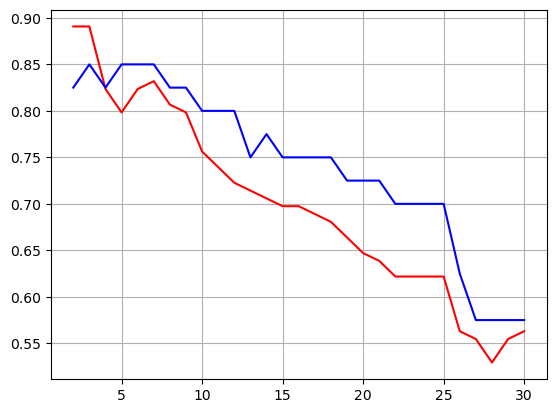

3


In [49]:
#n_neighbors를 바꿔보자
train_score = []
test_score = []

for i in range(2,31):
    kn = KNeighborsClassifier(n_neighbors=i)
    kn.fit(x_train_scaled, y_train)
    train_score.append(kn.score(x_train_scaled, y_train))
    test_score.append(kn.score(x_test_scaled, y_test))

import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(2,31), train_score, c='r')
plt.plot(np.arange(2,31), test_score, c='b')
plt.grid()
plt.show()

best_n = test_score.index(max(test_score))+2
print(best_n)

In [51]:
#분류 문제에서 정답 값의 종류가 2개 -> 이진분류
#분류 문제에서 정답 값의 종류가 2개보다 많으면 -> 다중분류

#사이킷런에서는 정답값이 문자여도 분류 문제 가능 -> 타깃값이 알아서 알파벳 순으로 매겨짐(unique로 출력한 순서랑 다름)
#사이킷런이 자동으로 정렬한 타깃값 확인
print(kn.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [59]:
#모델 학습으로 예측된 결과 확인하기
print(kn.predict(x_test_scaled[:5])) #결과

proba = kn.predict_proba(x_test_scaled[:5])
print(np.round(proba, decimals=4)) #확률

['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']
[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [72]:
#4번째 샘플로 비율이 맞는지 확인
distances, indexes = kn.kneighbors(x_test_scaled[3:4])
print(y_train[indexes])

# 1/3 = 0.333, 2/3 = 0.6667
#knn만 사용할 경우 계산할 수 있는 확률의 종류가 적음 -> 로지스틱 회귀

[['Roach' 'Perch' 'Perch']]


### 로지스틱 회귀 이진 분류

로지스틱 회귀: 분류 모델. 선형 방정식을 학습함. 데이터가 특정 범주에 속할 확률을 0~1 사이 값으로 예측하는 지도 학습 분류 알고리즘  

0~1 사이 값으로 예측하기 위해 **시그모이드** 함수(또는 로지스틱 함수)를 사용한다

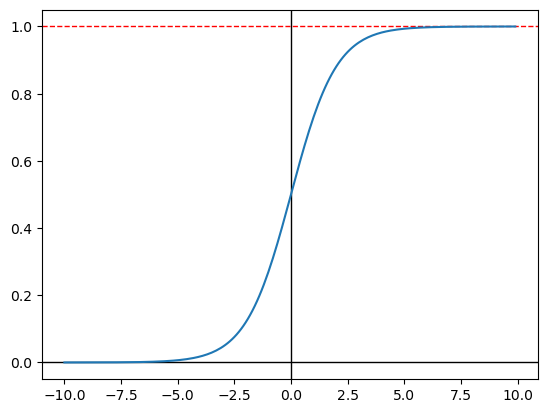

In [85]:
#시그모이드 함수
import matplotlib.pyplot as plt
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))
      
array = np.arange(-10, 10, 0.1)
plt.axvline(x=0, color='black', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1) 
plt.axhline(y=1, color='r', linestyle='--', linewidth=1) 
plt.plot(array, sigmoid(array))
plt.show()

#0.5보다 작으면 음성 0.5보다 크면 양성(0.5인 경우 라이브러리마다 다르지만 사이킷런은 음성으로 판단함)

In [87]:
#시그모이드 함수를 통해 이진분류를 하기 위해 데이터셋을 전처리
bream_smelt_indexes = (y_train == 'Bream') | (y_train == 'Smelt')
train_bream_smelt = x_train_scaled[bream_smelt_indexes]
target_bream_smelt = y_train[bream_smelt_indexes]

In [91]:
#모델 만들기
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_bream_smelt,target_bream_smelt)

print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [93]:
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99759855 0.00240145]
 [0.02735183 0.97264817]
 [0.99486072 0.00513928]
 [0.98584202 0.01415798]
 [0.99767269 0.00232731]]


In [97]:
print(lr.classes_)
#bream이 음성, smelt가 양성

['Bream' 'Smelt']


In [99]:
#모델의 계수 확인
print(lr.coef_, lr.intercept_)

[[-0.4037798  -0.57620209 -0.66280298 -1.01290277 -0.73168947]] [-2.16155132]


In [105]:
#시그모이드는 모델 학습을 통해 선형 방정식을 얻어냄 -> 선형 방정식을 통해 z값을 구하고 -> 시그모이드 함수를 통과 시켜 0~1의 확률을 구함
#시그모이드 과정을 직접 해보기

#1. z값 계산
decisions = lr.decision_function(train_bream_smelt[:5])
print(decisions)

#2. 시그모이드 함수로 감싸기
from scipy.special import expit
print(expit(decisions)) #--> 양성 클래스에 대한 값을 반환

[-6.02927744  3.57123907 -5.26568906 -4.24321775 -6.0607117 ]
[0.00240145 0.97264817 0.00513928 0.01415798 0.00232731]


### 로지스틱 회귀 다중 분류

-LogisiticRegression은 반복적인 알고리즘을 사용, max_iter매개 변수 사용(기본은 100)
-계수의 제곱을 규제(L2 규제), 매개변수 C사용(기본값1, 작을수록 규제가 커짐)

**질문: 로지스틱 회귀는 선형 방정식을 학습하는데 왜 반복 알고리즘을 사용하나요?**  
(선형 회귀처럼 선형식을 쓰는데 왜 로지스틱은 반복 알고리즘을 사용하는가?)


+L2 정규화(Regularization): 머신 러닝 모델의 과적합을 방지하기 위해 손실 함수에 추가되는 패널티 항.모델의 가중치의 제곱합에 대한 패널티를 적용함으로써, 모델 가중치의 크기를 가능한 작게 유지 L2 정규화는 각 특성이 출력에 미치는 영향을 낮게 유지하면서도 모델의 정확도를 최대한 높이려고 함

In [134]:
lr = LogisticRegression(C=20, max_iter=1000)

lr.fit(x_train_scaled, y_train)
print(lr.score(x_train_scaled, y_train))
print(lr.score(x_test_scaled, y_test))

0.9327731092436975
0.925


In [144]:
#결과
print(lr.predict(x_test_scaled[:5]))

print('\n',lr.classes_)
proba = lr.predict_proba(x_test_scaled[:5])
print(np.round(proba,decimals=3))

['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']

 ['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
[[0.    0.014 0.841 0.    0.136 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.935 0.015 0.016 0.   ]
 [0.011 0.034 0.306 0.007 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [146]:
print(lr.coef_.shape, lr.intercept_.shape)

(7, 5) (7,)


이진 분류: z값 계산해서 0.5를 기준으로 양성인지 음성인지 클래스를 나눔  
다중 분류: z값을 하나씩 계산(종류 수 만큼)해서 가장 높은 값을 선택, softmax함수를 사용하여 7개의 z값을 확률로 변환

소프트맥스: 수식 첨부하기 어려우니 간단히 설명하면 s1 = e^z1 / e^z1+...+e^z7 ... s7 = e^z7 / e^z1+...+e^z7


In [158]:
#softmax로 확률 구하는 방법 직접해보기
decision = lr.decision_function(x_test_scaled[:5])
print(np.round(decision, decimals=2))

from scipy.special import softmax
proba = softmax(decision, axis=1)
print('\n',np.round(proba, decimals=3))

[[ -6.5    1.03   5.16  -2.73   3.34   0.33  -0.63]
 [-10.86   1.93   4.77  -2.4    2.98   7.84  -4.26]
 [ -4.34  -6.23   3.17   6.49   2.36   2.42  -3.87]
 [ -0.68   0.45   2.65  -1.19   3.26  -5.75   1.26]
 [ -6.4   -1.99   5.82  -0.11   3.5   -0.11  -0.71]]

 [[0.    0.014 0.841 0.    0.136 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.935 0.015 0.016 0.   ]
 [0.011 0.034 0.306 0.007 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]
